## 0. 실험 요약

In [1]:
import pandas as pd
from IPython.display import display, HTML

# ── 분류 실험 구성 ────────────────────────────────────────────────────────
clf_desc = [
    'Morgan only (ECFP4, 2048 bits)',
    'MACCS only (167 bits)',
    'AtomPair only (2048 bits)',
    'Torsion only (2048 bits)',
    'RDKit Desc (~200종 물리화학적 기술자)',
    'Morgan + MACCS',
    'Morgan + MACCS + RDKit Desc',
    'All4FP (Morgan+MACCS+AP+Tor)',
    'All4FP + RDKit Desc',
]
clf_models = [
    'SVM (RBF kernel, class_weight=balanced)',
    'MLP (256→128, early_stopping)',
    'KNN (k=7, distance weight)',
    'XGBoost (scale_pos_weight)',
    'ExtraTrees (class_weight=balanced)',
    'HistGradientBoosting',
    'XGBoost + Optuna (25 trials)',
    'ExtraTrees + Optuna (20 trials)',
]

# ── 회귀 실험 구성 ────────────────────────────────────────────────────────
reg_desc = [
    'Morgan only (ECFP4, 2048 bits)',
    'MACCS only (167 bits)',
    'AtomPair only (2048 bits)',
    'Torsion only (2048 bits)',
    'RDKit Desc (~200종 물리화학적 기술자)',
    'All4FP (Morgan+MACCS+AP+Tor)',
    'Morgan + MACCS + RDKit Desc',
    'All4FP + RDKit Desc',
]
reg_models = [
    'SVM (RBF kernel)',
    'MLP (256→128, early_stopping)',
    'KNN (k=7, distance weight)',
    'XGBoost',
    'XGBoost + Optuna (25 trials)',
]

# ── 표 출력 ───────────────────────────────────────────────────────────────
max_rows = max(len(clf_desc), len(clf_models), len(reg_desc), len(reg_models))

def pad(lst, n):
    return lst + [''] * (n - len(lst))

df_summary = pd.DataFrame({
    '분류 디스크립터 (9종)' : pad(clf_desc,   max_rows),
    '분류 알고리즘 (8종)'   : pad(clf_models,  max_rows),
    '회귀 디스크립터 (8종)' : pad(reg_desc,   max_rows),
    '회귀 알고리즘 (5종)'   : pad(reg_models,  max_rows),
})

styled = (
    df_summary.style
    .set_caption('📋 전체 실험 구성 요약')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#4472C4'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 12px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('padding', '4px 12px'), ('font-size', '12px'),
                   ('border-bottom', '1px solid #ddd')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]},
    ])
    .hide(axis='index')
)
display(styled)

print(f'\n총 실험 조합:')
print(f'  분류: {len(clf_desc)} 디스크립터 × {len(clf_models)-2} 모델 + Optuna 2종')
print(f'  회귀: {len(reg_desc)} 디스크립터 × {len(reg_models)-1} 모델 + Optuna 1종')

분류 디스크립터 (9종),분류 알고리즘 (8종),회귀 디스크립터 (8종),회귀 알고리즘 (5종)
"Morgan only (ECFP4, 2048 bits)","SVM (RBF kernel, class_weight=balanced)","Morgan only (ECFP4, 2048 bits)",SVM (RBF kernel)
MACCS only (167 bits),"MLP (256→128, early_stopping)",MACCS only (167 bits),"MLP (256→128, early_stopping)"
AtomPair only (2048 bits),"KNN (k=7, distance weight)",AtomPair only (2048 bits),"KNN (k=7, distance weight)"
Torsion only (2048 bits),XGBoost (scale_pos_weight),Torsion only (2048 bits),XGBoost
RDKit Desc (~200종 물리화학적 기술자),ExtraTrees (class_weight=balanced),RDKit Desc (~200종 물리화학적 기술자),XGBoost + Optuna (25 trials)
Morgan + MACCS,HistGradientBoosting,All4FP (Morgan+MACCS+AP+Tor),
Morgan + MACCS + RDKit Desc,XGBoost + Optuna (25 trials),Morgan + MACCS + RDKit Desc,
All4FP (Morgan+MACCS+AP+Tor),ExtraTrees + Optuna (20 trials),All4FP + RDKit Desc,
All4FP + RDKit Desc,,,



총 실험 조합:
  분류: 9 디스크립터 × 6 모델 + Optuna 2종
  회귀: 8 디스크립터 × 4 모델 + Optuna 1종


## 1. 라이브러리 불러오기

In [2]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import AllChem, MACCSkeys, Descriptors

from sklearn.ensemble import (ExtraTreesClassifier, ExtraTreesRegressor,
                               HistGradientBoostingClassifier,
                               HistGradientBoostingRegressor)
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                              confusion_matrix, r2_score, mean_squared_error)
from sklearn.feature_selection import VarianceThreshold
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import matplotlib.font_manager as fm
def _set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available: return font
    return 'DejaVu Sans'
matplotlib.rcParams['font.family'] = _set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')


라이브러리 로드 완료


## 2. 데이터 로드 및 Feature Matrix 복원

`final_dataset_descriptors.csv`를 읽어 각 디스크립터 행렬을 복원합니다.

In [3]:
df_desc = pd.read_csv('final_dataset_descriptors.csv')
print(f'로드 완료: {df_desc.shape}')

morgan_cols = [c for c in df_desc.columns if c.startswith('Morgan_')]
maccs_cols  = [c for c in df_desc.columns if c.startswith('MACCS_')]
ap_cols     = [c for c in df_desc.columns if c.startswith('AP_')]
tor_cols    = [c for c in df_desc.columns if c.startswith('Tor_')]
phys_cols   = [c for c in df_desc.columns
               if c not in (['SMILES','label','logLD50']
                             + morgan_cols + maccs_cols + ap_cols + tor_cols)]

X_morgan = df_desc[morgan_cols].values.astype(np.float32)
X_maccs  = df_desc[maccs_cols].values.astype(np.float32)
X_ap     = df_desc[ap_cols].values.astype(np.float32)
X_tor    = df_desc[tor_cols].values.astype(np.float32)
X_phys   = df_desc[phys_cols].values.astype(np.float32)

y_clf = df_desc['label'].values.astype(int)
y_reg = df_desc['logLD50'].values.astype(float)

print(f'Morgan FP     : {X_morgan.shape}')
print(f'MACCS Keys    : {X_maccs.shape}')
print(f'AtomPair FP   : {X_ap.shape}')
print(f'Torsion FP    : {X_tor.shape}')
print(f'RDKit Desc    : {X_phys.shape}')
print(f'y_clf: {y_clf.sum()}개 독성 / {(y_clf==0).sum()}개 비독성')
print(f'y_reg: logLD50 {y_reg.min():.2f} ~ {y_reg.max():.2f}')


로드 완료: (6388, 6531)
Morgan FP     : (6388, 2048)
MACCS Keys    : (6388, 167)
AtomPair FP   : (6388, 2048)
Torsion FP    : (6388, 2048)
RDKit Desc    : (6388, 217)
y_clf: 1709개 독성 / 4679개 비독성
y_reg: logLD50 -1.92 ~ 4.85


## 3. 데이터 분할  (80% Train+Val / 20% Test)

In [4]:
idx = np.arange(len(y_clf))
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y_clf)

y_clf_tv   = y_clf[idx_trainval];  y_clf_test = y_clf[idx_test]
y_reg_tv   = y_reg[idx_trainval];  y_reg_test = y_reg[idx_test]
scale_pos_weight = float((y_clf_tv==0).sum()) / float((y_clf_tv==1).sum())

print(f'Train+Val : {len(idx_trainval)}개  독성={y_clf_tv.sum()} ({y_clf_tv.mean():.1%})')
print(f'Test      : {len(idx_test)}개  독성={y_clf_test.sum()} ({y_clf_test.mean():.1%})')
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

Train+Val : 5110개  독성=1367 (26.8%)
Test      : 1278개  독성=342 (26.8%)
scale_pos_weight = 2.74


## 4. 디스크립터 정제 (분산=0 + 상관 |r|>0.95 제거)

In [5]:
var_sel   = VarianceThreshold(threshold=0.0)
X_phys_tv = var_sel.fit_transform(X_phys[idx_trainval])
corr_matrix = np.corrcoef(X_phys_tv.T)
upper       = np.triu(np.abs(corr_matrix), k=1)
drop_cols   = set(int(i) for i in np.where((upper > 0.95).any(axis=0))[0])
keep_cols   = [i for i in range(X_phys_tv.shape[1]) if i not in drop_cols]
X_phys_clean = var_sel.transform(X_phys)[:, keep_cols]
print(f'RDKit Desc 정제: {X_phys.shape[1]} → {X_phys_clean.shape[1]}개')

RDKit Desc 정제: 217 → 188개


---
## Part A. 이진 분류 모델 (Acute Oral Toxicity)

**목표**: LD50 ≤ 300 mg/kg → 독성(1), > 300 → 비독성(0)  
**평가 지표**: Balanced Accuracy (주), ROC-AUC, Sensitivity, Specificity

### 5-A. 모델 학습 및 5-Fold CV 비교

In [6]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True)

# 디스크립터 — 개별(5종) + 조합(4종)
# 개별 성능을 먼저 확인하여 어떤 디스크립터가 유효한지 판단
descriptors_clf = {
    # ── 개별 디스크립터 ──────────────────────────────────────
    'Morgan only'   : X_morgan,
    'MACCS only'    : X_maccs,
    'AtomPair only' : X_ap,
    'Torsion only'  : X_tor,
    'RDKit Desc'    : X_phys_clean,
    # ── 조합 디스크립터 ──────────────────────────────────────
    'All4FP+CleanDesc'   : np.hstack([X_morgan, X_maccs, X_ap, X_tor, X_phys_clean]),
    'Morgan+MACCS+Desc'  : np.hstack([X_morgan, X_maccs, X_phys_clean]),
    'All4FP (FP only)'   : np.hstack([X_morgan, X_maccs, X_ap, X_tor]),
    'Morgan+MACCS'       : np.hstack([X_morgan, X_maccs]),
}

# 모델 정의 (4종 알고리즘)
models_clf = {
    # SVM (Pipeline: StandardScaler 포함)
    'SVM'         : Pipeline([('scaler', StandardScaler()),
                               ('clf', SVC(C=1.0, kernel='rbf',
                                           class_weight='balanced', probability=True))]),
    # MLP (2-hidden-layer)
    'MLP'         : Pipeline([('scaler', StandardScaler()),
                               ('clf', MLPClassifier(hidden_layer_sizes=(256, 128),
                                                     max_iter=300, early_stopping=True))]),
    # KNN
    'KNN'         : Pipeline([('scaler', StandardScaler()),
                               ('clf', KNeighborsClassifier(n_neighbors=7,
                                                             weights='distance', n_jobs=-1))]),
    # XGBoost
    'XGBoost'     : XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                   scale_pos_weight=scale_pos_weight,
                                   subsample=0.8, colsample_bytree=0.8,
                                   n_jobs=-1, verbosity=0, eval_metric='logloss'),
    # ExtraTrees
    'ExtraTrees'  : ExtraTreesClassifier(n_estimators=200, class_weight='balanced',
                                          max_features='sqrt', n_jobs=-1),
    # HistGradBoost
    'HistGradBoost': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                     max_depth=6),
}

results_clf = []
total = len(descriptors_clf) * len(models_clf); done = 0
for dname, X_d in descriptors_clf.items():
    X_tv = X_d[idx_trainval]
    for mname, model in models_clf.items():
        scores = cross_val_score(model, X_tv, y_clf_tv, cv=cv_clf,
                                 scoring='balanced_accuracy', n_jobs=-1)
        results_clf.append({'Descriptor': dname, 'Model': mname,
                            'Mean_BalAcc': scores.mean(), 'Std': scores.std()})
        done += 1
        print(f'[{done:2d}/{total}] {dname:30s} | {mname:18s} | BalAcc={scores.mean():.4f}±{scores.std():.4f}')

results_clf_df = pd.DataFrame(results_clf).sort_values('Mean_BalAcc', ascending=False).reset_index(drop=True)
print('\n=== Top 5 ===')
print(results_clf_df.head(5).to_string(index=False))

[ 1/54] Morgan only                    | SVM                | BalAcc=0.7273±0.0091
[ 2/54] Morgan only                    | MLP                | BalAcc=0.6985±0.0170
[ 3/54] Morgan only                    | KNN                | BalAcc=0.5835±0.0067
[ 4/54] Morgan only                    | XGBoost            | BalAcc=0.7466±0.0076
[ 5/54] Morgan only                    | ExtraTrees         | BalAcc=0.7397±0.0027
[ 6/54] Morgan only                    | HistGradBoost      | BalAcc=0.6947±0.0085
[ 7/54] MACCS only                     | SVM                | BalAcc=0.7689±0.0105
[ 8/54] MACCS only                     | MLP                | BalAcc=0.7218±0.0111
[ 9/54] MACCS only                     | KNN                | BalAcc=0.7309±0.0115
[10/54] MACCS only                     | XGBoost            | BalAcc=0.7784±0.0148
[11/54] MACCS only                     | ExtraTrees         | BalAcc=0.7393±0.0134
[12/54] MACCS only                     | HistGradBoost      | BalAcc=0.7303±0.0192
[13/

### 5-A-2. CV 결과 시각화 (Fig. A-1)

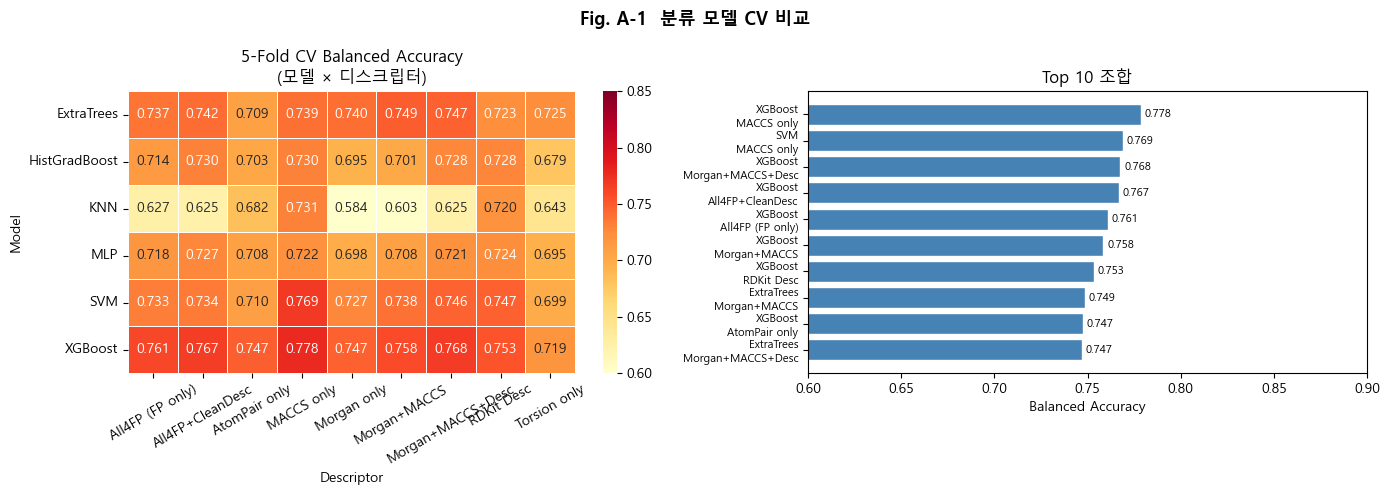

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히트맵
pivot = results_clf_df.pivot_table(index='Model', columns='Descriptor', values='Mean_BalAcc')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.6, vmax=0.85,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('5-Fold CV Balanced Accuracy\n(모델 × 디스크립터)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# Top 10 막대
top10 = results_clf_df.head(10)
colors = ['tomato' if v >= 0.78 else 'steelblue' for v in top10['Mean_BalAcc']]
bars = axes[1].barh(range(len(top10)),  top10['Mean_BalAcc'], color=colors, edgecolor='white')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels([f"{r['Model']}\n{r['Descriptor'][:20]}" for _, r in top10.iterrows()], fontsize=8)
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('Top 10 조합')
axes[1].invert_yaxis()
axes[1].set_xlim(0.6, 0.9)
for bar, v in zip(bars, top10['Mean_BalAcc']):
    axes[1].text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('Fig. A-1  분류 모델 CV 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part B. 회귀 모델 (log10 LD50 예측)

**목표**: log10(LD50) 수치 예측  
**평가 지표**: R² (주), RMSE  
**문헌 기준**: LD50 QSAR에서 R²=0.55~0.65가 일반적 상한 (Roy et al. 2015; Zhu et al. 2009)

### 5-B. 모델 학습 및 5-Fold CV 비교

In [8]:
from sklearn.base import clone

cv_reg = KFold(n_splits=5, shuffle=True)

# 디스크립터 — 개별(5종) + 조합(3종)
# 개별 성능을 먼저 확인하여 조합의 효과를 검증
descriptors_reg = {
    # ── 개별 디스크립터 ──────────────────────────────────────
    'Morgan only'   : X_morgan,
    'MACCS only'    : X_maccs,
    'AtomPair only' : X_ap,
    'Torsion only'  : X_tor,
    'RDKit Desc'    : X_phys_clean,
    # ── 조합 디스크립터 ──────────────────────────────────────
    'All4FP+CleanDesc'  : np.hstack([X_morgan, X_maccs, X_ap, X_tor, X_phys_clean]),
    'All4FP (FP only)'  : np.hstack([X_morgan, X_maccs, X_ap, X_tor]),
    'Morgan+MACCS+Desc' : np.hstack([X_morgan, X_maccs, X_phys_clean]),
}

# 모델 정의 (SVM / MLP / KNN / XGBoost)
models_reg = {
    'SVM'    : Pipeline([('scaler', StandardScaler()),
                          ('reg', SVR(C=1.0, kernel='rbf', epsilon=0.1))]),
    'MLP'    : Pipeline([('scaler', StandardScaler()),
                          ('reg', MLPRegressor(hidden_layer_sizes=(256, 128),
                                               max_iter=500, early_stopping=True))]),
    'KNN'    : Pipeline([('scaler', StandardScaler()),
                          ('reg', KNeighborsRegressor(n_neighbors=7,
                                                       weights='distance', n_jobs=-1))]),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                             subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, verbosity=0),
}

results_reg = []
total = len(descriptors_reg) * len(models_reg); done = 0
for dname, X_d in descriptors_reg.items():
    X_tv = X_d[idx_trainval]
    for mname, model in models_reg.items():
        scores = cross_val_score(model, X_tv, y_reg_tv, cv=cv_reg, scoring='r2')
        results_reg.append({'Descriptor': dname, 'Model': mname,
                             'Mean_R2': scores.mean(), 'Std': scores.std()})
        done += 1
        flag = ' ★' if scores.mean() >= 0.55 else ''
        print(f'[{done:2d}/{total}] {dname:22s} | {mname:8s} | R²={scores.mean():.4f}±{scores.std():.4f}{flag}')

results_reg_df = pd.DataFrame(results_reg).sort_values('Mean_R2', ascending=False).reset_index(drop=True)
print('\n=== Top 5 ===')
print(results_reg_df.head(5).to_string(index=False))


[ 1/32] Morgan only            | SVM      | R²=0.4111±0.0088
[ 2/32] Morgan only            | MLP      | R²=0.2356±0.0442
[ 3/32] Morgan only            | KNN      | R²=-0.0478±0.0637
[ 4/32] Morgan only            | XGBoost  | R²=0.4514±0.0234
[ 5/32] MACCS only             | SVM      | R²=0.4817±0.0186
[ 6/32] MACCS only             | MLP      | R²=0.4251±0.0134
[ 7/32] MACCS only             | KNN      | R²=0.4389±0.0194
[ 8/32] MACCS only             | XGBoost  | R²=0.5200±0.0344
[ 9/32] AtomPair only          | SVM      | R²=0.3939±0.0191
[10/32] AtomPair only          | MLP      | R²=0.2144±0.0258
[11/32] AtomPair only          | KNN      | R²=0.3947±0.0323
[12/32] AtomPair only          | XGBoost  | R²=0.4950±0.0082
[13/32] Torsion only           | SVM      | R²=0.3853±0.0209
[14/32] Torsion only           | MLP      | R²=0.2531±0.0422
[15/32] Torsion only           | KNN      | R²=0.3467±0.0332
[16/32] Torsion only           | XGBoost  | R²=0.4259±0.0285
[17/32] RDKit Desc     

In [3]:
# 전체 성능 요약
print('=== Part A. 분류 모델 CV 성능 (전체) ===')
print(results_clf_df[['Descriptor', 'Model', 'Mean_BalAcc', 'Std_BalAcc']].to_string(index=False))

print('\n=== Part B. 회귀 모델 CV 성능 (전체) ===')
print(results_reg_df[['Descriptor', 'Model', 'Mean_R2', 'Std_R2', 'Mean_RMSE']].to_string(index=False))

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² 히트맵
pivot_r2 = results_reg_df.pivot(index='Model', columns='Descriptor', values='Mean_R2')
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.0, vmax=0.7, linewidths=0.5, ax=axes[0])
axes[0].set_title('CV R² Heatmap\n(Descriptor x Model)')
axes[0].set_xlabel('Descriptor')
axes[0].set_ylabel('Model')

# 상위 10개 막대 그래프
top10 = results_reg_df.head(10)
bar_labels = [f"{r['Descriptor']}\n{r['Model']}" for _, r in top10.iterrows()]
axes[1].barh(bar_labels[::-1], top10['Mean_R2'][::-1],
             xerr=top10['Std_R2'][::-1], color='steelblue', capsize=4)
axes[1].axvline(0.5, color='red', linestyle='--', label='R² = 0.50')
axes[1].set_xlim(0, 0.8)
axes[1].set_title('Top 10 Combinations\n(5-Fold CV R²)')
axes[1].set_xlabel('R²')
axes[1].legend()

plt.tight_layout()
plt.show()

=== Part A. 분류 모델 CV 성능 (전체) ===


NameError: name 'results_clf_df' is not defined